In [9]:
import numpy as np
from psdebias import multitaper,lag_window,welch,periodogram, fit_psd, ar_spectrum, sample_ar
import matplotlib.pyplot as plt

In [10]:
def print_mse_bias_var(est, truth):
    le, lt = np.log(est), np.log(truth)
    MSE = np.mean((le - lt)**2)
    Bias = np.mean(le - lt)
    Var = MSE - Bias**2
    print(f"MSE: {MSE:.2f}, Bias: {Bias:.2f}, Var: {Var:.2f}")

# Demo

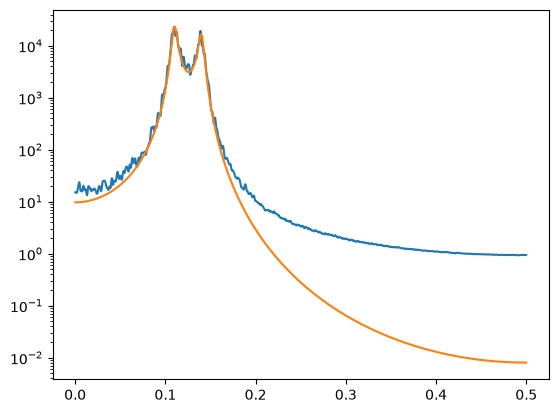

In [36]:
# --- simulate the paper's AR(4) process -------------------------------------
ar_poly = np.array([1.0, -2.7607, 3.8106, -2.6535, 0.9238])  # [1, -phi...]

n = 2**13
x = sample_ar(1, n, ar_poly, rng=np.random.default_rng(0))[0]

# --- any quadratic estimator; note the third output: the bias kernel --------
M =32
p=0.2
L = int(n / (M * (1-p)  + p))
step = int(L - p * L)

# est = welch(x,segment_length=L, n_segments =M,step=step,taper=np.ones(L))
est = lag_window(x,window="bartlett",lag=n//15)
# est = multitaper(x,nw=12)
true_spectrum = ar_spectrum(est.freqs,ar_poly, sd=1.0)

plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs, true_spectrum)

In [37]:
from psdebias import dquad

In [43]:
gamma = np.zeros(len(est.freqs))
d = 64
gamma[d:-d:d] = 1


In [44]:
dquad_est = dquad(est.psd,est.freqs, gamma=gamma, kernel=est.kernel, n_time=n)

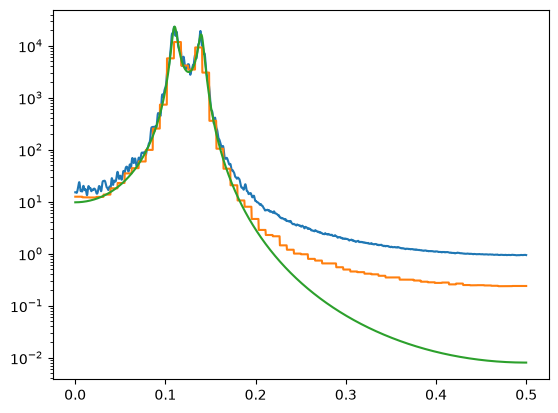

In [45]:
plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs, dquad_est)
plt.semilogy(est.freqs, true_spectrum)

## Fit

In [46]:
number_of_knots = 128 
knot_spacing = int(np.ceil(len(est.freqs))/number_of_knots)

In [48]:
# --- the full PSDebias workflow in one call ---------------------------------
fit = fit_psd(
    est, # Estimate in SpectralEstimate class
    n_time=n,   # the estimator's window, for the diagnostic/debias
    knot_spacing=knot_spacing,               # one candidate knot per 4 frequency bins
    rng=np.random.default_rng(),
    n_iterations=5_000, warmup=2_000,
)

In [49]:
fit.mean          # posterior-mean PSD (always linear scale)
fit.std           # pointwise posterior std
fit.expected_knots, fit.acceptance_rate

(47.3112, 0.30542857142857144)

PSD
MSE: 8.90, Bias: 2.37, Var: 3.31
PSDebias
MSE: 1.40, Bias: 0.80, Var: 0.76


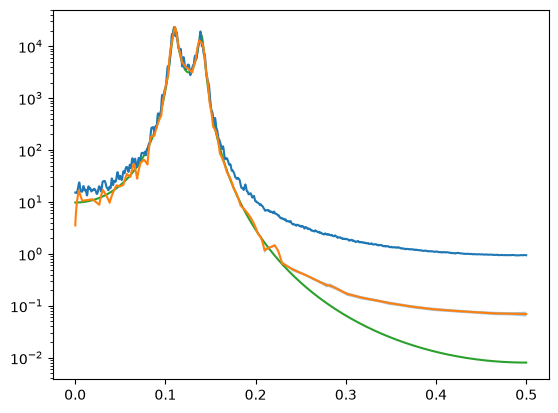

In [50]:
plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs, fit.mean)
plt.fill_between(est.freqs, fit.mean - fit.std, fit.mean + fit.std,alpha=0.4)
plt.semilogy(est.freqs, true_spectrum,zorder=1)
print("PSD")
print_mse_bias_var(est.psd, true_spectrum)
print("PSDebias")
print_mse_bias_var(fit.mean, true_spectrum)

## dwelch

In [ ]:
from psdebias import dwelch_b0
gamma = np.zeros(len(est.freqs), dtype=np.int8)
gamma[::32] = 1                                   # a uniform mesh
_, debiased = dwelch_b0(est.psd, est.freqs, gamma=gamma, kernel=est.kernel, n_time=L)

In [ ]:
plt.semilogy(est.freqs, debiased)
plt.semilogy(est.freqs,fit.mean)
plt.semilogy(est.freqs, est.psd)
plt.semilogy(est.freqs,true_spectrum)

print("PSD")
print_mse_bias_var(est.psd, true_spectrum)
print("PSDebias")
print_mse_bias_var(fit.mean, true_spectrum)
print("DQuad")
print_mse_bias_var(debiased, true_spectrum)

# Sunspot

In [ ]:
x = np.genfromtxt("../data/SN_y_tot_V2.0.csv",delimiter=';').T[1]
x -= np.mean(x)

In [ ]:
plt.plot(x)

In [ ]:
M = 3
N = len(x)
p = 0.5
L = int(N // (M * (1-p) + p))
step = int((1-p) * L)

In [ ]:
# est = welch(x,segment_length=L,n_segments=M,step=step,taper=np.hamming(L))
est = multitaper(x,nw=5)
est = lag_window(x,window='bartlett',lag=len(x)//6)
per = periodogram(x)
plt.semilogy(est.freqs, est.psd)
plt.semilogy(per.freqs, per.psd)

In [ ]:
# --- the full PSDebias workflow in one call ---------------------------------
fit = fit_psd(
    est,
    n_time=len(x),   # the estimator's window, for the diagnostic/debias
    knot_spacing=1,               # one candidate knot per 1 frequency bins
    rng=np.random.default_rng(1),
    n_iterations=50_000, warmup=20_000,
)

In [ ]:
plt.figure(figsize=(10,10))

plt.semilogy(est.freqs, fit.mean)
plt.semilogy(est.freqs, est.psd,alpha=0.4,linestyle='dotted')
plt.semilogy(per.freqs, per.psd,lw=0.8,linestyle='dashed',zorder=1)

plt.fill_between(est.freqs, fit.mean - fit.std, fit.mean + fit.std,alpha=0.3)
print_mse_bias_var(fit.mean, est.psd)